In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, shutil
import torch
import time
import pdb
import matplotlib.pyplot as plt
plt.rcParams.update({"text.usetex": True,
                     "axes.spines.right" : False,
                     "axes.spines.top" : False,
                     "font.size": 15
                    }
                   )
tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}
import head
import numpy as np
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_model
from botorch.acquisition.monte_carlo import  qExpectedImprovement
from matplotlib.cm import ScalarMappable
from scipy.spatial import distance
import pdb
from botorch.utils.sampling import draw_sobol_samples
from botorch.optim.optimize import optimize_acqf
from botorch.acquisition import PosteriorMean
from matplotlib import cm
import matplotlib
np.random.seed(0)

N_SAMPLES = 100
BATCH_SIZE = 2
N_ITERATIONS = 256
NUM_RESTARTS = 64 
RAW_SAMPLES = 1024
N_INIT_SAMPLES = 2

VERBOSE = False

INFO: Using numpy backend


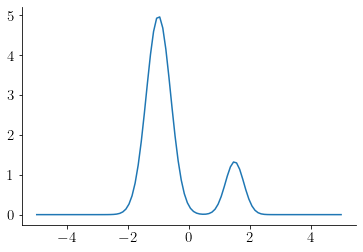

In [3]:
lambda_ = np.linspace(-5,5,num=N_SAMPLES)
def gaussian(mu,sig, lambda_):
    scale = 1/(np.sqrt(2*np.pi)*sig)
    return scale*np.exp(-np.power(lambda_ - mu, 2.) / (2 * np.power(sig, 2.)))

def ground_truth(m1,s1,m2,s2):
    y = lambda x: 5*gaussian(m1,s1, x) + gaussian(m2,s2, x)
    return y(lambda_)

TARGET = [-1,0.4,1.5,0.3]
yt = ground_truth(*TARGET)
fig, ax = plt.subplots()
ax.plot(lambda_, yt)
plt.show()

In [4]:
# define search space
param_m1 = [-5,5]
param_s1 = [1e-3,1]
param_m2 = [-5,5]
param_s2 = [1e-3,1]
bounds = torch.tensor((param_m1, param_s1,param_m2,param_s2)).T.to(**tkwargs)

In [5]:
def draw_random_batch(n_samples=6):
    train_x = draw_sobol_samples(
        bounds=bounds,n=1, q=n_samples, 
        seed=torch.randint(2021, (1,)).item()
    ).squeeze(0)
    return train_x

for _ in range(10):
    random_x = draw_random_batch(n_samples=N_INIT_SAMPLES)

## Metric selection

In [6]:
from geomstats.geometry.poincare_half_space import PoincareHalfSpace
from geomstats.geometry.euclidean import Euclidean
from geomstats.geometry.functions import L2Space, SRVF
Rn = Euclidean(N_SAMPLES)
L2 = L2Space(lambda_)
srvf = SRVF(lambda_)

metric = 'L2'

if metric=='L2':
    d = lambda xi,yi : -L2.metric.dist(yi, yt)
elif metric=='Rn':
    d = lambda xi,yi : -float(Rn.metric.dist(yi, yt))
elif metric=='srvf':
    d = lambda xi,yi : -srvf.metric.dist(yi, yt)  
else:
    raise NotImplementedError('Metric %s is not implemented'%metric)

In [7]:
class Oracle:
    def __init__(self, metric):
        self.metric = metric
        self.expt_id = 0
        self.expt = {}
        
    def evaluate(self, x):
        """Scoring function at a given input location
        Uses the simulator sim to generate response spectra at a given locations
        and return a similarity score to target spectra
        """
        x_np = x.cpu().numpy()
        yi = ground_truth(*x_np)
        dist = self.metric(x_np, yi)

        self.expt[self.expt_id] = [lambda_, yi, dist]
    
        return torch.tensor([dist])
    
    def batch_evaluate(self, x):
        #print('Current experiment id : ', self.expt_id)
        out = []
        for xi in x.squeeze(1):
            out.append(self.evaluate(xi))
            self.expt_id += 1
        return torch.stack(out, dim=0).to(**tkwargs)
    
oracle = Oracle(d)
print(oracle.__dict__)

{'metric': <function <lambda> at 0x7fed753b8160>, 'expt_id': 0, 'expt': {}}


In [8]:
def initialize_model(train_x, train_obj):
    # define models for objective and constraint
    model = SingleTaskGP(train_x, train_obj, 
    outcome_transform=Standardize(m=train_obj.shape[-1]))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    return mll, model

In [9]:
def selector(f,oracle, q = BATCH_SIZE):
    new_x, _ = optimize_acqf(
        acq_function=f,
        bounds=bounds,
        q=q,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES, 
        sequential=False,
    )
    new_obj = oracle.batch_evaluate(new_x)
    return new_x, new_obj

## Main optimization loop

In [10]:
# Evaluate the randomly selected points
train_x = random_x.clone()
train_obj = oracle.batch_evaluate(train_x)
if VERBOSE:
    print('Generated %d samples randomly'%N_INIT_SAMPLES, train_x.shape, train_obj.shape)
    for i in range(N_INIT_SAMPLES):
        print('%d\t%s\t%s'%(i, train_x[i,...].numpy(), train_obj[i,...].numpy()))
        
# run N_ITERATIONS rounds of BayesOpt after the initial random batch
if VERBOSE:
    print('Sampled ID \t Locations \t Objectives')
    
for iteration in range(N_ITERATIONS):
    mll, model = initialize_model(train_x, train_obj)

    if VERBOSE:
        print('Iteration : %d/%d'%(iteration, N_ITERATIONS))
    # fit the models
    fit_gpytorch_model(mll)

    # define the acquisition module
    #acquisition = qUpperConfidenceBound(model, beta=0.1)
    best_f = train_obj.max(axis=0).values
    acquisition = qExpectedImprovement(model, best_f = best_f)
    
    # optimize acquisition functions and get new observations
    new_x, new_obj = selector(acquisition, oracle)
    if VERBOSE:
        for i in range(BATCH_SIZE):
            print('%d\t%s\t%s'%(i, new_x[i,...].numpy(), 
                                new_obj[i,...].numpy()))

    # update training points
    train_x = torch.cat([train_x, new_x])
    train_obj = torch.cat([train_obj, new_obj])
    
    if iteration%10==0:
        print('Current iteration: %d, best distance: %.2f'%(iteration, train_obj.max()))
    
expt = oracle.expt

Current iteration: 0, best distance: -1.52
Current iteration: 10, best distance: -1.24
Current iteration: 20, best distance: -1.15
Current iteration: 30, best distance: -0.32
Current iteration: 40, best distance: -0.16
Current iteration: 50, best distance: -0.16
Current iteration: 60, best distance: -0.16
Current iteration: 70, best distance: -0.16
Current iteration: 80, best distance: -0.16
Current iteration: 90, best distance: -0.16
Current iteration: 100, best distance: -0.16


NotPSDError: Matrix not positive definite after repeatedly adding jitter up to 1.0e-06.

In [ ]:
batch_number = torch.cat(
    [torch.zeros(N_INIT_SAMPLES), 
     torch.arange(1, N_ITERATIONS+1).repeat(BATCH_SIZE, 1).t().reshape(-1)]
).numpy()

def plot_best_trace(ax, train_x, train_obj, target):
    train_x = train_x.cpu().numpy()
    proximities = distance.cdist(train_x, np.asarray(TARGET).reshape(1,4))
    trace = np.asarray([min(proximities[batch_number<=b]) for b in np.unique(batch_number)])
    return ax.plot(np.arange(N_ITERATIONS+1),trace)

fig, ax = plt.subplots()
ax.axhline(0, label='Optimal', ls='--', lw='2.0', c='k')
plot_best_trace(ax, train_x, train_obj, TARGET)
ax.set_xlabel('Batch number')
ax.set_ylabel(r'$||x-x_{t}||_{2}$')
plt.show()

In [ ]:
fig, ax = plt.subplots()
batches = np.unique(batch_number)
best_ind = [np.argmax(train_obj.numpy()[batch_number<=b]) for b in batches]
best_loc = train_x[best_ind].numpy()
ax.plot(lambda_, yt, 'k--', lw=2.0)
cmap = cm.get_cmap('coolwarm')
norm = matplotlib.colors.Normalize(vmin=0, vmax = N_ITERATIONS+1)
for i, bind in enumerate(best_ind):
    wl, ext, _ = expt[bind]
    ax.plot(wl, ext, color=cmap(norm(i)))
ax.set_xlim([-5,5])
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$\phi(x)$', fontsize=14)
cax = plt.axes([0.95, 0.2, 0.01, 0.6])        
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
cbar.ax.set_ylabel('Batch number', rotation=270)
cbar.ax.get_yaxis().labelpad = 15
plt.show()